# Hurricane Harvey Damage Classification Project

## Part 1: Data Preprocessing and Visualization

In [1]:
# Import all necessary libraries for data loading, preprocessing, visualization, and modeling
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

2025-11-06 04:08:41.268092: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 04:08:42.453554: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-06 04:08:42.453702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-06 04:08:42.610012: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-06 04:08:42.996387: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 04:08:43.006926: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
# Define dataset paths
DATASET_DIR = 'datasets'
DAMAGE_DIR = os.path.join(DATASET_DIR, 'damage')
NO_DAMAGE_DIR = os.path.join(DATASET_DIR, 'no_damage')

# List image files in each class
damage_images = [os.path.join(DAMAGE_DIR, fname) for fname in os.listdir(DAMAGE_DIR) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]
no_damage_images = [os.path.join(NO_DAMAGE_DIR, fname) for fname in os.listdir(NO_DAMAGE_DIR) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Number of damaged images: {len(damage_images)}")
print(f"Number of non-damaged images: {len(no_damage_images)}")

# Inspect a few images for shape and format
sample_damage_img = Image.open(damage_images[0])
sample_no_damage_img = Image.open(no_damage_images[0])
print(f"Damaged image size: {sample_damage_img.size}, format: {sample_damage_img.format}")
print(f"Non-damaged image size: {sample_no_damage_img.size}, format: {sample_no_damage_img.format}")

Number of damaged images: 14170
Number of non-damaged images: 7152
Damaged image size: (128, 128), format: JPEG
Non-damaged image size: (128, 128), format: JPEG


In [4]:
# Set image size for resizing
# Originally, the image size is (128, 128), but this is too much for our model to handle
scaler = 2
IMG_SIZE = (128 // scaler, 128 // scaler)  # Small size for faster training and compatibility with LeNet-5

# Function to load and preprocess images
def load_and_preprocess(image_paths, label):
    images = []
    labels = []
    for path in image_paths:
        img = Image.open(path).convert('RGB')
        img = img.resize(IMG_SIZE)
        img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
        images.append(img_array)
        labels.append(label)
    return images, labels

# Preprocess all images
X_damage, y_damage = load_and_preprocess(damage_images, 1)
X_no_damage, y_no_damage = load_and_preprocess(no_damage_images, 0)

# Combine and create full dataset
X = np.array(X_damage + X_no_damage)
y = np.array(y_damage + y_no_damage)

print(f"Total images: {len(X)}")
print(f"Image shape: {X[0].shape}")

# Train, validation, and test splits
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Total images: 21322
Image shape: (64, 64, 3)
Training set size: 14925
Validation set size: 3198
Test set size: 3199


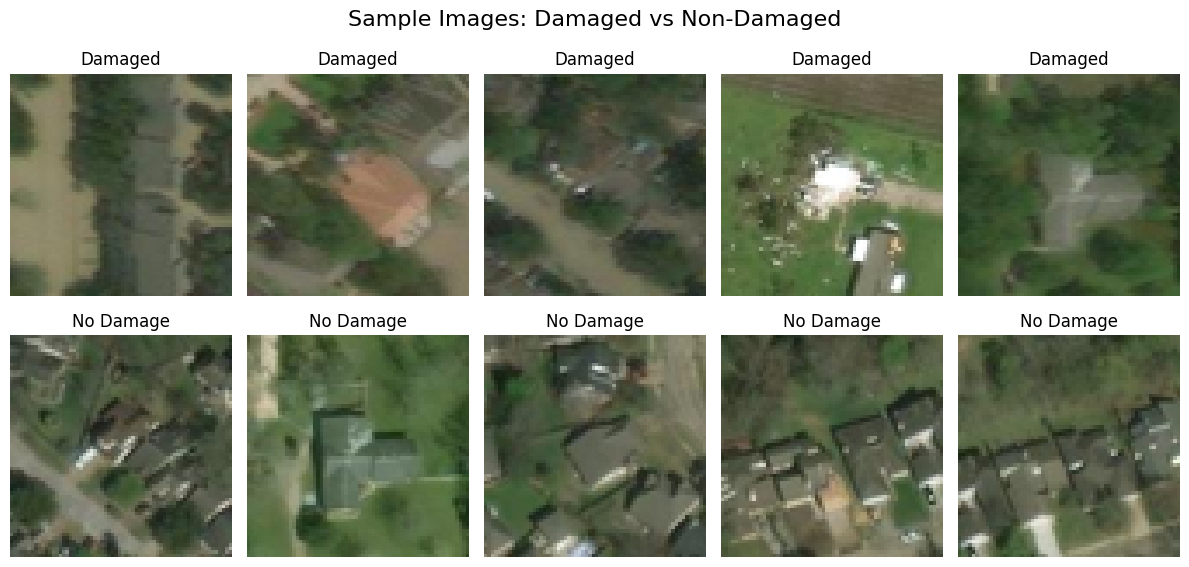

In [5]:
n = 5

# Sample images from both classes
fig, axes = plt.subplots(2, n, figsize=(12, 6))
fig.suptitle('Sample Images: Damaged vs Non-Damaged', fontsize=16)

for i in range(n):
    # Damaged
    img = Image.open(damage_images[i]).resize(IMG_SIZE)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Damaged')
    axes[0, i].axis('off')
    # Non-Damaged
    img = Image.open(no_damage_images[i]).resize(IMG_SIZE)
    axes[1, i].imshow(img)
    axes[1, i].set_title('No Damage')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## Part 2: Model Design, Training, and Evaluation
Three different neural network architectures:
1. Dense (fully connected) ANN
2. LeNet-5 CNN
3. Alternate-LeNet-5 CNN (as described in the referenced paper)

Each model has been:
- Implemented
- Trained
- Evaluated

### Dense (Fully Connected) ANN

In [7]:
# Flatten images
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_val_flat = X_val.reshape((X_val.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# Build fully connected CNN
ann_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_ann = ann_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=3,
    batch_size=4,
    verbose=2
)

# Evaluate on test set
test_loss_ann, test_acc_ann = ann_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Dense ANN Test Accuracy: {test_acc_ann:.4f}")

Epoch 1/3
3732/3732 - 36s - loss: 0.6531 - accuracy: 0.6555 - val_loss: 0.6380 - val_accuracy: 0.6645 - 36s/epoch - 10ms/step
Epoch 2/3
3732/3732 - 33s - loss: 0.6385 - accuracy: 0.6646 - val_loss: 0.6384 - val_accuracy: 0.6645 - 33s/epoch - 9ms/step
Epoch 3/3
3732/3732 - 33s - loss: 0.6385 - accuracy: 0.6646 - val_loss: 0.6384 - val_accuracy: 0.6645 - 33s/epoch - 9ms/step
Dense ANN Test Accuracy: 0.6646


We observe that the test accuracy of the dense ANN is 0.6646, which is relatively low for a binary classification task. That means that this model has learned some pattern, but not enough to determine damaged vs non-damaged reliably. This makes sense, as vanilla ANNs are not great at image recognition, since flattening data causes our data to lose spatial information. It is expected that a CNN will perform better since they can exploit spatial locality.

### LeNet-5 CNN Architecture

In [9]:
# Build the LeNet-5 CNN architecture
lenet5_model = keras.Sequential([
    keras.layers.Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(*IMG_SIZE, 3), padding='same'),
    keras.layers.AveragePooling2D(),
    keras.layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
    keras.layers.AveragePooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dense(84, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

lenet5_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_lenet5 = lenet5_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=2
)

# Evaluate on test set
test_loss_lenet5, test_acc_lenet5 = lenet5_model.evaluate(X_test, y_test, verbose=0)
print(f"LeNet-5 Test Accuracy: {test_acc_lenet5:.4f}")

Epoch 1/15
467/467 - 12s - loss: 0.4810 - accuracy: 0.7761 - val_loss: 0.3595 - val_accuracy: 0.8643 - 12s/epoch - 25ms/step
Epoch 2/15
467/467 - 10s - loss: 0.3384 - accuracy: 0.8649 - val_loss: 0.4306 - val_accuracy: 0.8208 - 10s/epoch - 22ms/step
Epoch 3/15
467/467 - 10s - loss: 0.2629 - accuracy: 0.9031 - val_loss: 0.2484 - val_accuracy: 0.9056 - 10s/epoch - 22ms/step
Epoch 4/15
467/467 - 10s - loss: 0.2061 - accuracy: 0.9195 - val_loss: 0.2269 - val_accuracy: 0.9121 - 10s/epoch - 22ms/step
Epoch 5/15
467/467 - 10s - loss: 0.1685 - accuracy: 0.9345 - val_loss: 0.2916 - val_accuracy: 0.8931 - 10s/epoch - 21ms/step
Epoch 6/15
467/467 - 10s - loss: 0.1700 - accuracy: 0.9337 - val_loss: 0.2228 - val_accuracy: 0.9131 - 10s/epoch - 21ms/step
Epoch 7/15
467/467 - 10s - loss: 0.1409 - accuracy: 0.9439 - val_loss: 0.2384 - val_accuracy: 0.9178 - 10s/epoch - 22ms/step
Epoch 8/15
467/467 - 10s - loss: 0.1044 - accuracy: 0.9606 - val_loss: 0.2297 - val_accuracy: 0.9278 - 10s/epoch - 22ms/step


This time, the LeNet-5 test accuracy was 0.9312, which is significantly better than that of the vanilla dense ANN. The model now captures basic spatial features like edges and textures. It should be noted that switching the hidden layers' activation function from `tanh` to `relu` increased the accuracy from 0.8365, since ReLU tends to perform better in modern TensorFlow pipelines.

### Alternate-LeNet-5 CNN Architecture

In [10]:
# Alternate-LeNet-5 architecture based on the referenced paper
alt_lenet5_model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(5, 5), activation='relu', input_shape=(*IMG_SIZE, 3), padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, kernel_size=(5, 5), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dense(84, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

alt_lenet5_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_alt_lenet5 = alt_lenet5_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=2
)

# Evaluate on test set
test_loss_alt_lenet5, test_acc_alt_lenet5 = alt_lenet5_model.evaluate(X_test, y_test, verbose=0)
print(f"Alternate-LeNet-5 Test Accuracy: {test_acc_alt_lenet5:.4f}")

Epoch 1/15
467/467 - 34s - loss: 0.4547 - accuracy: 0.7942 - val_loss: 0.2983 - val_accuracy: 0.8862 - 34s/epoch - 73ms/step
Epoch 2/15
467/467 - 32s - loss: 0.2686 - accuracy: 0.9003 - val_loss: 0.3810 - val_accuracy: 0.8477 - 32s/epoch - 68ms/step
Epoch 3/15
467/467 - 33s - loss: 0.2164 - accuracy: 0.9183 - val_loss: 0.2508 - val_accuracy: 0.9059 - 33s/epoch - 70ms/step
Epoch 4/15
467/467 - 32s - loss: 0.1714 - accuracy: 0.9345 - val_loss: 0.1808 - val_accuracy: 0.9321 - 32s/epoch - 68ms/step
Epoch 5/15
467/467 - 34s - loss: 0.1441 - accuracy: 0.9448 - val_loss: 0.1857 - val_accuracy: 0.9284 - 34s/epoch - 73ms/step
Epoch 6/15
467/467 - 33s - loss: 0.1216 - accuracy: 0.9540 - val_loss: 0.1930 - val_accuracy: 0.9303 - 33s/epoch - 70ms/step
Epoch 7/15
467/467 - 32s - loss: 0.1074 - accuracy: 0.9585 - val_loss: 0.2757 - val_accuracy: 0.8959 - 32s/epoch - 69ms/step
Epoch 8/15
467/467 - 32s - loss: 0.0979 - accuracy: 0.9619 - val_loss: 0.1899 - val_accuracy: 0.9303 - 32s/epoch - 70ms/step


Finally, the alternate LeNet-5 test accuracy was 0.9359, which outperforms both the original LeNet-5 CNN and the dense ANN. Since it uses max pooling instead of average pooling, it is better at detecting distinct features in images, which is useful for classification tasks.

### Model Comparison and Selection

In [13]:
# Compare test accuracies of all models
print("\nMODEL TEST ACCURACIES:")
print(f"- Dense ANN: {test_acc_ann:.4f}")
print(f"- LeNet-5 CNN: {test_acc_lenet5:.4f}")
print(f"- Alternate-LeNet-5 CNN: {test_acc_alt_lenet5:.4f}")

# Select the best model
accuracies = [test_acc_ann, test_acc_lenet5, test_acc_alt_lenet5]
models = ['Dense ANN', 'LeNet-5 CNN', 'Alternate-LeNet-5 CNN']
best_model_idx = np.argmax(accuracies)
print(f"\nBest model for deployment:\n{models[best_model_idx]} (Accuracy: {accuracies[best_model_idx]:.4f})")


MODEL TEST ACCURACIES:
- Dense ANN: 0.6646
- LeNet-5 CNN: 0.9312
- Alternate-LeNet-5 CNN: 0.9359

Best model for deployment:
Alternate-LeNet-5 CNN (Accuracy: 0.9359)
